In [1]:
from enum import Enum

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Utils

In [14]:
import pickle
import types


def save_session(filename='session.pkl'):
    session_data = {}
    for name, value in globals().items():
        if name.startswith('__') or isinstance(value, types.ModuleType) or isinstance(value, types.FunctionType):
            continue
        try:
            pickle.dumps(value)
            session_data[name] = value
        except Exception as e:
            print(f"Переменная '{name}' пропущена: {e}")

    with open(filename, 'wb') as f:
        pickle.dump(session_data, f)
    print(f"Сессия сохранена в {filename}")


def load_session(filename='session.pkl'):
    with open(filename, 'rb') as f:
        session_data = pickle.load(f)

    globals().update(session_data)
    print(f"Сессия загружена из {filename}")


In [ ]:
load_session(filename='session_fix.pkl')

# Алгоритм

### Ядра

In [2]:
# Ядра, distance - вычисленное расстояние
def uniform_kernel(distance):
    return 0.5 * (distance < 1)


def triangular_kernel(distance):
    return (1 - np.abs(distance)) * (distance < 1)


def epanechnikov_kernel(distance):
    return 0.75 * (1 - (distance ** 2)) * (distance < 1)


def quartic_kernel(distance):
    return (15 / 16) * ((1 - (distance ** 2)) ** 2) * (distance < 1)


def triweight_kernel(distance):
    return (35 / 32) * ((1 - (distance ** 2)) ** 3) * (distance < 1)


def tricube_kernel(distance):
    return (70 / 81) * ((1 - (np.abs(distance) ** 3)) ** 3) * (distance < 1)


def gaussian_kernel(distance):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-(distance ** 2) / 2)


class Kernel(Enum):
    UNIFORM = uniform_kernel
    TRIANGULAR = triangular_kernel
    EPANECHNIKOV = epanechnikov_kernel
    QUARTIC = quartic_kernel
    TRIWEIGHT = triweight_kernel
    TRICUBE = tricube_kernel
    GAUSSIAN = gaussian_kernel

    def __call__(self, *args, **kwargs):
        self.value(*args, **kwargs)


### Метрики

In [3]:
# Метрики расстояний, x1 и x2 - векторы

def cosine_distance(x1, x2):
    return 1 - np.dot(x1, x2) / (np.linalg.norm(x1) * np.linalg.norm(x2))


def minkowski_distance(x1, x2, p=3):
    return np.sum(np.abs(np.subtract(x1, x2)) ** p) ** (1 / p)


def euclidean_distance(x1, x2):
    return minkowski_distance(x1, x2, 1)


def manhattan_distance(x1, x2):
    return minkowski_distance(x1, x2, 2)


def chebyshev_distance(x1, x2):
    return np.max(np.abs(np.subtract(x1, x2)))


class Metric(Enum):
    COSINE = cosine_distance
    MINKOWSKI = minkowski_distance
    EUCLIDEAN = euclidean_distance
    MANHATTAN = manhattan_distance
    CHEBYSHEV = chebyshev_distance

    def __call__(self, *args, **kwargs):
        self.value(*args, **kwargs)


### Метод ближайших соседей

In [4]:
from sklearn.neighbors import NearestNeighbors


class KNearestNeighbors:
    def __init__(self, k_neighbors=5, metric=Metric.EUCLIDEAN, kernel=Kernel.GAUSSIAN, window=None):
        '''
        :param k_neighbors: количество ближайших соседей
        :param metric: метрика для вычисления расстояния
        :param kernel: функция ядра для взвешивания (используется, если window не None)
        :param window: если None — базовый k-NN. Если число > 0 — фиксированное окно, если <= 0 — нефиксированное окно.
        '''
        self.k_neighbors = k_neighbors
        self.metric = metric
        self.kernel = kernel
        self.window = window
        self.X_train = None
        self.y_train = None
        self.apriori_weights = None

    def fit(self, X_train, y_train, apriori_weights=None):
        self.X_train, self.y_train = X_train, y_train
        self.apriori_weights = np.ones(X_train.shape[0]) if apriori_weights is None else apriori_weights

    def _calculate_distances(self, X_test):
        if self.window is not None and self.window > 0:
            nn = NearestNeighbors(radius=self.window, metric=self.metric)
            nn.fit(self.X_train)
            distances, indices = nn.radius_neighbors(X_test)
        elif self.k_neighbors > 0 and self.window is not None and self.window <= 0:
            nn = NearestNeighbors(n_neighbors=self.k_neighbors + 1, metric=self.metric)
            nn.fit(self.X_train)
            distances, indices = nn.kneighbors(X_test)
        elif self.k_neighbors is not None:
            nn = NearestNeighbors(n_neighbors=self.k_neighbors, metric=self.metric)
            nn.fit(self.X_train)
            distances, indices = nn.kneighbors(X_test)
        else:
            raise ValueError("Нужно задать либо размер окна, либо количество соседей")

        return distances, indices

    def _calculate_weight(self, distances, indices):
        if self.window is not None:  # kNN с окном
            current_h = np.max(distances) if self.window <= 0 else self.window
            if current_h == 0: current_h = 1e9
            weights = self.kernel(distances / current_h)
        else:  # Базовый kNN
            weights = np.ones(distances.shape[0])

        if self.apriori_weights is not None:
            weights *= self.apriori_weights[indices]

        return weights

    def predict_proba(self, X_test):
        distances, indices = self._calculate_distances(X_test)

        pred_with_proba = []
        for i in range(len(distances)):
            distances_i = distances[i]
            indices_i = indices[i]

            if len(distances_i) == 0:
                pred_with_proba.append((np.nan, 1))
                continue

            weights = self._calculate_weight(distances_i, indices_i)

            weighted_y_sum = np.bincount(self.y_train[indices_i], weights=weights)
            total_sum = np.sum(weighted_y_sum)
            max_idx = np.argmax(weighted_y_sum)
            proba = weighted_y_sum[max_idx] / total_sum if total_sum != 0 else 1
            pred_with_proba.append((max_idx, proba))

        return np.array(pred_with_proba)

    def predict(self, X_test):
        return np.array([pred_with_proba[0] for pred_with_proba in self.predict_proba(X_test)])


In [18]:
def simple_lowess(X, y, knn, kernel=Kernel.GAUSSIAN):
    new_apriori_weights = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        X_except_i = np.delete(X, i, axis=0)
        y_except_i = np.delete(y, i, axis=0)

        knn.fit(X_except_i, y_except_i)

        y_pred_i = knn.predict(np.array([X[i]]))[0]

        new_apriori_weights[i] = kernel(0 if y[i] == y_pred_i else 1)

    return new_apriori_weights


def proba_lowess(X, y, knn, kernel=Kernel.GAUSSIAN):
    new_apriori_weights = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        X_except_i = np.delete(X, i, axis=0)
        y_except_i = np.delete(y, i, axis=0)

        knn.fit(X_except_i, y_except_i)

        (y_pred_i, prob) = knn.predict_proba(np.array([X[i]]))[0]
        new_apriori_weights[i] = 1 - prob if y[i] == y_pred_i else prob

    new_apriori_weights = kernel(np.array(new_apriori_weights))
    return new_apriori_weights

# Набор данных

In [6]:
# path = './wine_quality/winequality-red.csv'
# data = pd.read_csv(path, sep=';')

path = './Titanic-Dataset.csv'
data = pd.read_csv(path, sep=',')

data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [7]:
scaler = StandardScaler()

data = data.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1)
data['Sex'] = data['Sex'].astype('category').cat.codes
data['Age'] = data['Age'].fillna(data['Age'].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
data['Embarked'] = data['Embarked'].astype('category').cat.codes

X = data.drop("Survived", axis=1)
y = data["Survived"]

X_normalized = scaler.fit_transform(X)

X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

X_train_val, X_test, y_train_val, y_test = train_test_split(X_normalized.to_numpy(), y.to_numpy(), test_size=0.15,
                                                            random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.176, random_state=42)

print(f'Размер тренировочной выборки: {X_train.shape}')
print(f'Размер валидационной выборки: {X_val.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер тренировочной выборки: (623, 7)
Размер валидационной выборки: (134, 7)
Размер тестовой выборки: (134, 7)


# Гиперпараметры

In [9]:
k_neighbors = list(range(1, 30))

window_values = [None, 0, 3, 6, 9, 12]

metrics = [Metric.COSINE, Metric.MINKOWSKI, Metric.EUCLIDEAN, Metric.MANHATTAN, Metric.CHEBYSHEV]
# metrics = [Metric.COSINE]

kernels = [Kernel.UNIFORM, Kernel.TRIANGULAR, Kernel.EPANECHNIKOV, Kernel.QUARTIC, Kernel.TRIWEIGHT, Kernel.TRICUBE, Kernel.GAUSSIAN]
# kernels = [Kernel.GAUSSIAN]

param_grid = {
    'k_neighbors': k_neighbors,
    'window': window_values,
    'metric': metrics,
    'kernel': kernels
}

In [10]:
def evaluate_model(y_true, y_pred):
    correct_predictions = np.sum(y_true == y_pred)
    return correct_predictions / y_true.shape[0]


def grid_search_func(X_train, y_train, X_test, y_test, k_values, metrics, kernels, window_values):
    best_accuracy = 0
    best_params = {}
    results = []

    total_i = len(k_values) * len(metrics) * len(window_values) * len(kernels)
    print(f"Total steps: {total_i}")
    i = 1
    for k in k_values:
        for metric in metrics:
            for kernel in kernels:
                for window in window_values:
                    # Создание модели с текущими гиперпараметрами
                    model = KNearestNeighbors(k_neighbors=k, metric=metric, kernel=kernel, window=window)
                    model.fit(X_train, y_train)

                    # Предсказание на тренировочной и тестовой выборках
                    y_val_pred = model.predict(X_val)
                    y_test_pred = model.predict(X_test)

                    # Вычисление точности
                    val_accuracy = evaluate_model(y_val, y_val_pred)
                    test_accuracy = evaluate_model(y_test, y_test_pred)

                    print(f"step={i}", k, metric, kernel, window, int(val_accuracy * 1000) / 1000,
                          int(test_accuracy * 1000) / 1000)

                    # Сохранение результатов
                    results.append((k, metric, kernel, window, val_accuracy, test_accuracy))
                    i += 1

                    # Проверка на лучшее значение
                    if val_accuracy > best_accuracy:
                        best_accuracy = val_accuracy
                        best_params = {
                            'k_neighbors': k,
                            'metric': metric,
                            'kernel': kernel,
                            'window': window,
                            'val_accuracy': val_accuracy,
                            'test_accuracy': test_accuracy,
                        }

    return best_params, results

In [11]:
my_best_params, my_results = grid_search_func(X_train, y_train, X_test, y_test, k_neighbors, metrics, kernels, window_values)

Total steps: 6090
step=1 1 <function cosine_distance at 0x00000255FC2DB7E0> <function uniform_kernel at 0x00000255FC2DB060> None 0.768 0.798
step=2 1 <function cosine_distance at 0x00000255FC2DB7E0> <function uniform_kernel at 0x00000255FC2DB060> 0 0.805 0.776
step=3 1 <function cosine_distance at 0x00000255FC2DB7E0> <function uniform_kernel at 0x00000255FC2DB060> 3 0.611 0.582
step=4 1 <function cosine_distance at 0x00000255FC2DB7E0> <function uniform_kernel at 0x00000255FC2DB060> 6 0.611 0.582
step=5 1 <function cosine_distance at 0x00000255FC2DB7E0> <function uniform_kernel at 0x00000255FC2DB060> 9 0.611 0.582
step=6 1 <function cosine_distance at 0x00000255FC2DB7E0> <function uniform_kernel at 0x00000255FC2DB060> 12 0.611 0.582
step=7 1 <function cosine_distance at 0x00000255FC2DB7E0> <function triangular_kernel at 0x00000255FC2DB240> None 0.768 0.798
step=8 1 <function cosine_distance at 0x00000255FC2DB7E0> <function triangular_kernel at 0x00000255FC2DB240> 0 0.805 0.776
step=9 1 

In [12]:
my_best_params

{'k_neighbors': 12,
 'metric': <function __main__.minkowski_distance(x1, x2, p=3)>,
 'kernel': <function __main__.triangular_kernel(distance)>,
 'window': 0,
 'val_accuracy': np.float64(0.8805970149253731),
 'test_accuracy': np.float64(0.7835820895522388)}

In [13]:
my_results

[(1,
  <function __main__.cosine_distance(x1, x2)>,
  <function __main__.uniform_kernel(distance)>,
  None,
  np.float64(0.7686567164179104),
  np.float64(0.7985074626865671)),
 (1,
  <function __main__.cosine_distance(x1, x2)>,
  <function __main__.uniform_kernel(distance)>,
  0,
  np.float64(0.8059701492537313),
  np.float64(0.7761194029850746)),
 (1,
  <function __main__.cosine_distance(x1, x2)>,
  <function __main__.uniform_kernel(distance)>,
  3,
  np.float64(0.6119402985074627),
  np.float64(0.582089552238806)),
 (1,
  <function __main__.cosine_distance(x1, x2)>,
  <function __main__.uniform_kernel(distance)>,
  6,
  np.float64(0.6119402985074627),
  np.float64(0.582089552238806)),
 (1,
  <function __main__.cosine_distance(x1, x2)>,
  <function __main__.uniform_kernel(distance)>,
  9,
  np.float64(0.6119402985074627),
  np.float64(0.582089552238806)),
 (1,
  <function __main__.cosine_distance(x1, x2)>,
  <function __main__.uniform_kernel(distance)>,
  12,
  np.float64(0.611940298

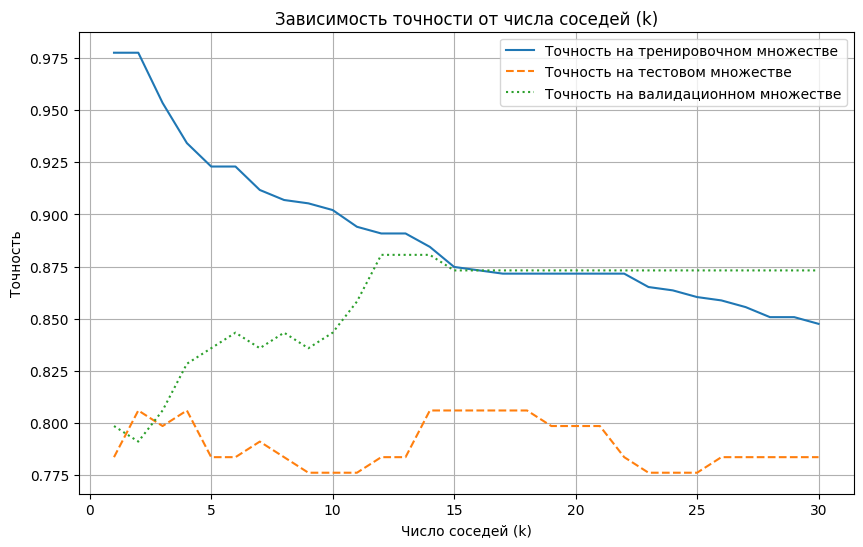

In [16]:
best_metric = Metric.MINKOWSKI
best_kernel = Kernel.TRIANGULAR
best_window = 0

k_values = range(1, 31)

train_accuracies = []
val_accuracies = []
test_accuracies = []

for k in k_values:
    knn_model = KNearestNeighbors(k_neighbors=k, metric=best_metric, kernel=best_kernel, window=best_window)

    # Обучаем модель
    knn_model.fit(X_train, y_train)

    # Предсказания на тренировочном, валидационном и тестовом наборах
    y_train_pred = knn_model.predict(X_train)
    y_val_pred = knn_model.predict(X_val)
    y_test_pred = knn_model.predict(X_test)

    # Оценка точности
    train_accuracies.append(evaluate_model(y_train, y_train_pred))
    val_accuracies.append(evaluate_model(y_val, y_val_pred))
    test_accuracies.append(evaluate_model(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Точность на тренировочном множестве')
plt.plot(k_values, test_accuracies, label='Точность на тестовом множестве', linestyle='--')
plt.plot(k_values, val_accuracies, label='Точность на валидационном множестве', linestyle=':')
plt.xlabel('Число соседей (k)')
plt.ylabel('Точность')
plt.title('Зависимость точности от числа соседей (k)')
plt.legend()
plt.grid(True)
plt.show()

# Поиск аномалий

In [19]:
# Base
knn_without_lowess = KNearestNeighbors(k_neighbors=14, metric=best_metric, kernel=best_kernel, window=best_window)
knn_without_lowess.fit(X_train, y_train)
y_pred_without_lowess = knn_without_lowess.predict(X_test)

# Lowess simple
knn_with_simple_lowess = KNearestNeighbors(k_neighbors=14, metric=best_metric, kernel=best_kernel, window=best_window)
apriori_weights_simple = simple_lowess(X_train, y_train, knn_with_simple_lowess, best_kernel)
knn_with_simple_lowess.fit(X_train, y_train, apriori_weights=apriori_weights_simple)
y_pred_with_simple_lowess = knn_with_simple_lowess.predict(X_test)

# Lowess simple
knn_with_proba_lowess = KNearestNeighbors(k_neighbors=14, metric=best_metric, kernel=best_kernel, window=best_window)
apriori_weights_proba = proba_lowess(X_train, y_train, knn_with_proba_lowess, best_kernel)
knn_with_proba_lowess.fit(X_train, y_train, apriori_weights=apriori_weights_proba)
y_pred_with_proba_lowess = knn_with_proba_lowess.predict(X_test)

In [21]:
accuracy_without_lowess = accuracy_score(y_test, y_pred_without_lowess)
print(f"Точность модели до применения LOWESS: {accuracy_without_lowess:.4f}")

accuracy_with_simple_lowess = accuracy_score(y_test, y_pred_with_simple_lowess)
print(f"Точность модели после применения LOWESS (simple): {accuracy_with_simple_lowess:.4f}")

accuracy_with_proba_lowess = accuracy_score(y_test, y_pred_with_proba_lowess)
print(f"Точность модели после применения LOWESS (proba): {accuracy_with_proba_lowess:.4f}")

Точность модели до применения LOWESS: 0.8060
Точность модели после применения LOWESS (simple): 0.7985
Точность модели после применения LOWESS (proba): 0.8134


In [22]:
save_session(filename="session_fix.pkl")

Переменная 'get_ipython' пропущена: Can't pickle local object 'ScriptMagics._make_script_magic.<locals>.named_script_magic'
Переменная 'exit' пропущена: Can't pickle local object 'ScriptMagics._make_script_magic.<locals>.named_script_magic'
Переменная 'quit' пропущена: Can't pickle local object 'ScriptMagics._make_script_magic.<locals>.named_script_magic'
Сессия сохранена в session_fix.pkl
